In [5]:
import timm
import torch
import torch.nn as nn
import torch.nn.init as init
def init_weights(module):
    if isinstance(module, nn.Linear):
        init.kaiming_uniform_(module.weight, nonlinearity="relu")
        if module.bias is not None:
            init.zeros_(module.bias)
    elif (
        isinstance(module, nn.Conv2d)
        or isinstance(module, nn.Conv1d)
        or isinstance(module, nn.Conv3d)
    ):
        init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
        if module.bias is not None:
            init.zeros_(module.bias)
    elif isinstance(module, nn.BatchNorm2d) or isinstance(module, nn.BatchNorm1d):
        init.ones_(module.weight)
        init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        init.normal_(module.weight, mean=0.0, std=0.01)
    elif isinstance(module, nn.LSTM) or isinstance(module, nn.GRU):
        for name, param in module.named_parameters():
            if "weight_ih" in name:
                init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                init.orthogonal_(param.data)
            elif "bias" in name:
                init.zeros_(param.data)
class SimplePoseCNN(nn.Module):
    def __init__(self, num_keypoints=11, dropout_rate = 0.5):
        super().__init__()
        # self.encoder = nn.Sequential(
        #    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 128x128
        #    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64x64
        #    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 32x32
        # )
        model = timm.create_model(
            "resnet50",
            output_stride=8,
            pretrained=True,
            # features_only=True,
            # drop_path_rate=drop_path_rate,
            # drop_block_rate=drop_block_rate,
        )
        self.encoder = nn.Sequential(
            model.conv1,
            model.bn1,
            model.act1,
            model.maxpool,
            model.layer1,
            model.layer2,
            model.layer3,
            model.layer4,
            # model.global_pool,  # for global average pooled features
        )
        self.head = nn.Sequential(
            nn.Conv2d(2048, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),  # Dropout 
            # nn.ConvTranspose2d(
            #    in_channels=256, out_channels=64, kernel_size=4, stride=2, padding=1
            # ),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),  # 64x64
            nn.Conv2d(64, num_keypoints, 1),
        )
        # self.head = self.head.apply(init_weights)
    def forward(self, x):
        x = self.encoder(x)
        return self.head(x) # Output shape: (B, K, 64, 64)

In [11]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [20]:
class PoseDataset(Dataset):
    def __init__(
        self, 
        img_dir,
        annotation_file, 
        input_size = (256,256),
        heatmap_size = (64,64),
        sigma = 2, #how big the blob will be on heatmap (gaussian)
        transform = None, 
        mode= 'train'
    ):
        self.img_dir = Path(img_dir)
        self.input_size = input_size 
        self.heatmap_size = heatmap_size
        self.sigma = sigma 
        self.mode = mode 
        
        with open(annotation_file, 'r') as f:
            self.pose_data = json.load(f)
        
        self.img_id_2_file = {
            img['id']: img['file_name']
            for img in self.pose_data ['images']
        }
        
        self.samples = self._create_samples()
        
        if transform is None:
            if mode == 'train':
                self.transform = transforms.Compose([
                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2 ),
                    transforms.ToTensor(),
                    transforms.Normalize(
                        #image net stats 
                        mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]
                    )
                ])
            else:
                self.transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]
                    )
                ])
                
        else:
            self.transform = transform
            
    def _create_samples(self):
        return[
            {
            'image_id': ann['image_id'],
            'bbox': ann['bbox'],
            'keypoints': np.array(ann['keypoints']).reshape(-1, 3),
            'annotation_id': ann['id']
        }
        for ann in self.pose_data['annotations']
    ]
        
    def _get_transform_matrix(self, bbox, output_size):
            #affine transformation matrix 
            #handles aspect ration 
        x, y, w, h = bbox
        
        aspect_ratio = output_size[0] / output_size[1]
        center = np.array([x + w * 0.5, y + h * 0.5])
        
        if w > aspect_ratio * h:
            h = w / aspect_ratio
        elif w < aspect_ratio * h:
            w = h * aspect_ratio
        scale = np.array([w / output_size[0], h / output_size[1]])
        
        return center, scale
    
    def _affine_transform(self, point, center, scale, output_size, inv=False):
        scale_tmp = scale * 200.0 
        
        src_w = scale_tmp[0]
        src_h = scale_tmp[1]
        src_center = center
    
        src = np.zeros((3, 2), dtype=np.float32)
        src[0, :] = src_center
        src[1, :] = src_center + np.array([0, -src_h * 0.5])
        src[2, :] = src_center + np.array([src_w * 0.5, 0])
        
        dst = np.zeros((3, 2), dtype=np.float32)
        dst[0, :] = [output_size[0] * 0.5, output_size[1] * 0.5]
        dst[1, :] = [output_size[0] * 0.5, output_size[1] * 0.5 - output_size[1] * 0.5]
        dst[2, :] = [output_size[0] * 0.5 + output_size[0] * 0.5, output_size[1] * 0.5]
        
        if inv:
            trans = cv2.getAffineTransform(np.float32(dst), np.float32(src))
        else:
            trans = cv2.getAffineTransform(np.float32(src), np.float32(dst))
        
        point_transformed = np.dot(trans, np.array([point[0], point[1], 1.0]))
        return point_transformed[:2]
    
    def _generate_heatmap(self, keypoints, heatmap_size):

        num_keypoints = len(keypoints)
        heatmaps = np.zeros((num_keypoints, heatmap_size[0], heatmap_size[1]), dtype=np.float32)
        valid_mask = np.zeros(num_keypoints, dtype=np.float32)
        
        scale_x = heatmap_size[1] / self.input_size[1]
        scale_y = heatmap_size[0] / self.input_size[0]
        
        for i, (x, y, visibility) in enumerate(keypoints):
            if visibility == 0: 
                continue
            
            x_hm = int(x * scale_x)
            y_hm = int(y * scale_y)
            
            if x_hm < 0 or x_hm >= heatmap_size[1] or y_hm < 0 or y_hm >= heatmap_size[0]:
                continue
            

            tmp_size = self.sigma * 3
            ul = [int(x_hm - tmp_size), int(y_hm - tmp_size)]
            br = [int(x_hm + tmp_size + 1), int(y_hm + tmp_size + 1)]
            
            if ul[0] >= heatmap_size[1] or ul[1] >= heatmap_size[0] or br[0] < 0 or br[1] < 0:
                continue
            
            size = 2 * tmp_size + 1
            x_range = np.arange(0, size, 1, np.float32)
            y_range = x_range[:, np.newaxis]
            x0 = y0 = size // 2
            g = np.exp(-((x_range - x0) ** 2 + (y_range - y0) ** 2) / (2 * self.sigma ** 2))

            g_x = max(0, -ul[0]), min(br[0], heatmap_size[1]) - ul[0]
            g_y = max(0, -ul[1]), min(br[1], heatmap_size[0]) - ul[1]
            
            img_x = max(0, ul[0]), min(br[0], heatmap_size[1])
            img_y = max(0, ul[1]), min(br[1], heatmap_size[0])
            
            heatmaps[i, img_y[0]:img_y[1], img_x[0]:img_x[1]] = \
                g[g_y[0]:g_y[1], g_x[0]:g_x[1]]
            
            valid_mask[i] = 1.0 if visibility == 2 else 0.5 
        
        return heatmaps, valid_mask
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        img_path = self.img_dir / self.img_id_2_file[sample['image_id']] 
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        bbox = sample['bbox']  # [x, y, w, h]
        keypoints = sample['keypoints'].copy()  # (num_kpts, 3)
        

        center, scale = self._get_transform_matrix(bbox, self.input_size)

        trans = self._get_affine_transform_matrix(center, scale, self.input_size)
        

        img_cropped = cv2.warpAffine(
            img,
            trans,
            (self.input_size[1], self.input_size[0]),
        )
        
        for i in range(len(keypoints)):
            if keypoints[i, 2] > 0:  
                keypoints[i, :2] = self._affine_transform(
                    keypoints[i, :2], center, scale, self.input_size
                )
        
        heatmaps, valid_mask = self._generate_heatmap(keypoints, self.heatmap_size)
        
        img_pil = Image.fromarray(img_cropped)
        img_tensor = self.transform(img_pil)
        
        return {
            'image': img_tensor,
            'heatmaps': torch.from_numpy(heatmaps).float(),
            'valid_mask': torch.from_numpy(valid_mask).float(),
            'keypoints': torch.from_numpy(keypoints).float(),  
            'center': torch.from_numpy(center).float(),
            'scale': torch.from_numpy(scale).float(),
        }
    
    def _get_affine_transform_matrix(self, center, scale, output_size):

        scale_tmp = scale * 200.0
        src_w = scale_tmp[0]
        src_h = scale_tmp[1]
        
        src = np.zeros((3, 2), dtype=np.float32)
        src[0, :] = center
        src[1, :] = center + np.array([0, -src_h * 0.5])
        src[2, :] = center + np.array([src_w * 0.5, 0])
        
        dst = np.zeros((3, 2), dtype=np.float32)
        dst[0, :] = [output_size[1] * 0.5, output_size[0] * 0.5]
        dst[1, :] = [output_size[1] * 0.5, 0]
        dst[2, :] = [output_size[1], output_size[0] * 0.5]
        
        return cv2.getAffineTransform(np.float32(src), np.float32(dst))


def create_dataloaders(
    train_img_dir,
    train_ann_file,
    val_img_dir,
    val_ann_file,
    batch_size=32,
    num_workers=4
):
    train_dataset = PoseDataset(
        img_dir=train_img_dir,
        annotation_file=train_ann_file,
        input_size=(256, 256),
        heatmap_size=(64, 64),
        mode='train'
    )
    
    val_dataset = PoseDataset(
        img_dir=val_img_dir,
        annotation_file=val_ann_file,
        input_size=(256, 256),
        heatmap_size=(64, 64),
        mode='val'
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader

In [21]:
class HeatmapLoss(nn.Module): #MSE loss 
    def __init__(self):
        super().__init__()
    def forward(self, pred_heatmaps, target_heatmaps, valid_mask):
        loss = F.mse_loss(pred_heatmaps, target_heatmaps, reduction='none') #loss per keypoint 
        loss = loss.mean(dim=[2, 3]) 
        loss = loss * valid_mask 
        return loss.sum() / (valid_mask.sum() + 1e-8)

In [22]:
import torch.optim as optim
from tqdm import tqdm

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        images = batch['image'].to(device)
        target_heatmaps = batch['heatmaps'].to(device)
        valid_mask = batch['valid_mask'].to(device)
        
        pred_heatmaps = model(images)  #(B, K, 64, 64)
    
        loss = criterion(pred_heatmaps, target_heatmaps, valid_mask)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader) #avg loss per batch for an epoch 


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            images = batch['image'].to(device)
            target_heatmaps = batch['heatmaps'].to(device)
            valid_mask = batch['valid_mask'].to(device)
            
            pred_heatmaps = model(images)
            loss = criterion(pred_heatmaps, target_heatmaps, valid_mask)
            
            total_loss += loss.item()
    
    return total_loss / len(val_loader)


Epoch 1/100


Validation: 100%|██████████| 9/9 [00:02<00:00,  3.51it/s]


Train Loss: 0.0504 | Val Loss: 0.0035
best model saved with validation loss of  (val_loss: 0.0035)

Epoch 2/100


Validation: 100%|██████████| 9/9 [00:02<00:00,  4.21it/s]


Train Loss: 0.0058 | Val Loss: 0.0029
best model saved with validation loss of  (val_loss: 0.0029)

Epoch 3/100


...

Train Loss: 0.0005 | Val Loss: 0.0009

Epoch 99/100


Validation: 100%|██████████| 9/9 [00:02<00:00,  4.05it/s]


Train Loss: 0.0005 | Val Loss: 0.0009
best model saved with validation loss of  (val_loss: 0.0009)

Epoch 100/100


Validation: 100%|██████████| 9/9 [00:02<00:00,  4.08it/s]


Train Loss: 0.0005 | Val Loss: 0.0009
best model saved with validation loss of  (val_loss: 0.0009)


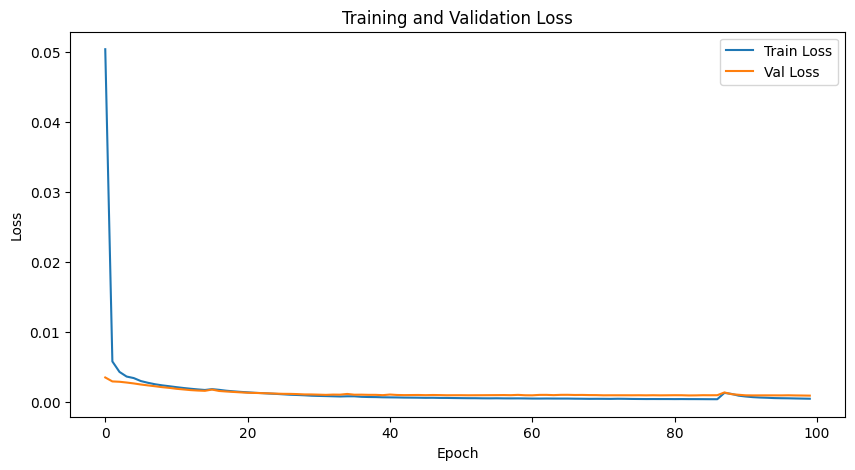

In [23]:
def main():
    num_epochs = 100
    batch_size = 32
    learning_rate = 1e-3
    device = torch.device('cuda:0') 
    train_losses = []
    val_losses = []
    train_loader, val_loader = create_dataloaders(
        train_img_dir='/data/marci/SMAS_UTK1/train',
        train_ann_file='/data/marci/SMAS_UTK1/train/_annotations.coco.json',
        val_img_dir='/data/marci/SMAS_UTK1/valid',
        val_ann_file='/data/marci/SMAS_UTK1/valid/_annotations.coco.json',
        batch_size=batch_size,
        num_workers=4
    )
    
    model = SimplePoseCNN(num_keypoints=11).to(device)  
    
    criterion = HeatmapLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_loss = float('inf')
    

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'best_model.pth')
            print(f"best model saved with validation loss of  (val_loss: {val_loss:.4f})")
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

if __name__ == '__main__':
    main()